In [1]:
import os, glob, json, time, random
from pathlib import Path
import numpy as np
import torch
from PIL import Image
import matplotlib.pyplot as plt

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
device = "cuda" if torch.cuda.is_available() else ("mps" if torch.backends.mps.is_available() else "cpu")
print(torch.__version__, device)

MEMBER_DIR = Path.cwd().parent          # .../task3_gan/manjot
TASK_DIR = MEMBER_DIR.parent            # .../task3_gan
DATA_DIR = TASK_DIR / "data"
MONET_DIR, PHOTO_DIR = DATA_DIR / "monet_jpg", DATA_DIR / "photo_jpg"
OUT_DIR = MEMBER_DIR / "outputs"; OUT_DIR.mkdir(exist_ok=True)
print(MEMBER_DIR)
print("Monet folder exists:", MONET_DIR.exists(), "| Photo folder exists:", PHOTO_DIR.exists())

2.8.0+cu128 cuda
/workspace/lab1/task3_gan/manjot
Monet folder exists: True | Photo folder exists: True


Monet (domain A): 300   Photo (domain B): 7038


images that are not 256x256 RGB: 0
{'mu_real': (2048,), 'sigma_real': (2048, 2048), 'feats_real': (300, 2048)}


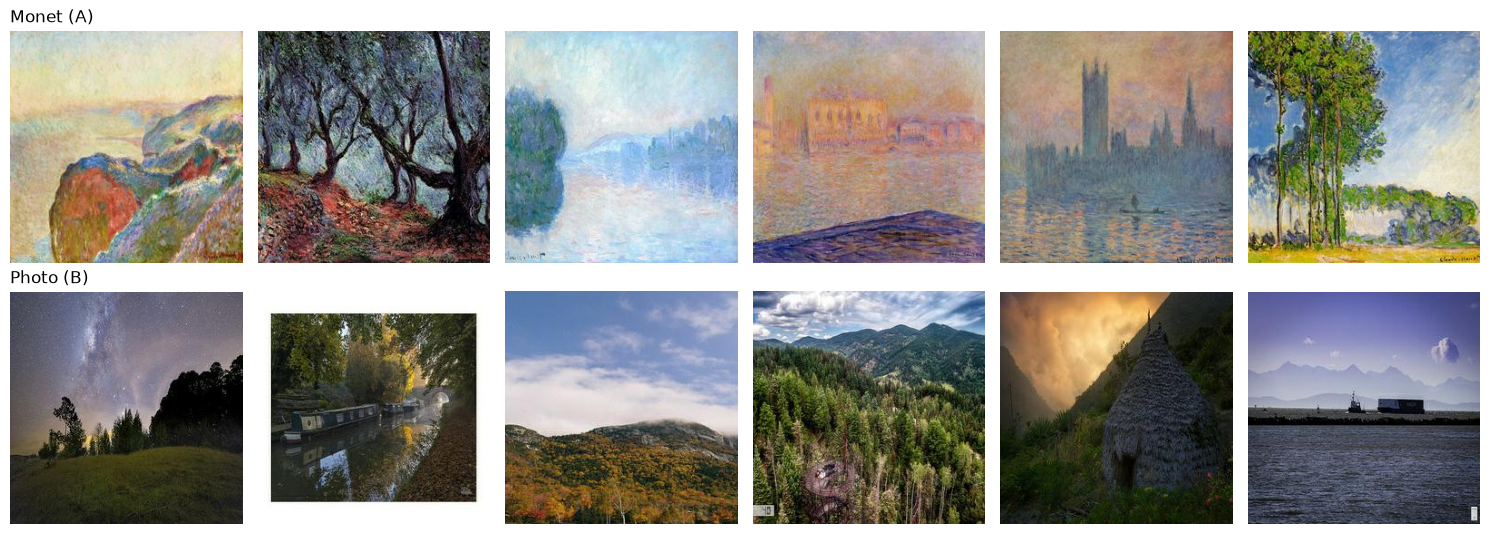

In [2]:
monet_files = sorted(glob.glob(str(MONET_DIR / "*.jpg")))
photo_files = sorted(glob.glob(str(PHOTO_DIR / "*.jpg")))
print(f"Monet (domain A): {len(monet_files)}   Photo (domain B): {len(photo_files)}")

# check every image is 256x256 RGB
bad = []
for f in monet_files + photo_files:
    with Image.open(f) as im:
        if im.size != (256, 256) or im.mode != "RGB":
            bad.append(f)
print("images that are not 256x256 RGB:", len(bad))

stats = np.load(DATA_DIR / "real_stats.npz")
print({k: stats[k].shape for k in stats.files})

fig, ax = plt.subplots(2, 6, figsize=(15, 5.5))
for i in range(6):
    ax[0, i].imshow(Image.open(monet_files[i])); ax[0, i].axis("off")
    ax[1, i].imshow(Image.open(random.choice(photo_files))); ax[1, i].axis("off")
ax[0, 0].set_title("Monet (A)", loc="left"); ax[1, 0].set_title("Photo (B)", loc="left")
plt.tight_layout(); plt.savefig(OUT_DIR / "data_examples.png", dpi=120); plt.show()



dataset length (steps per epoch at batch 1): 7038
Monet batch: (1, 3, 256, 256) range [-1.00, 1.00]
Photo batch: (1, 3, 256, 256) range [-1.00, 1.00]


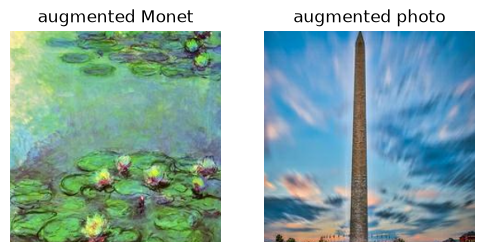

In [3]:
import torchvision.transforms as T
from torch.utils.data import Dataset, DataLoader

train_tf = T.Compose([
    T.Resize(286, interpolation=T.InterpolationMode.BICUBIC),  # enlarge slightly...
    T.RandomCrop(256),                                         # ...then take a random 256x256 crop (jitter)
    T.RandomHorizontalFlip(),
    T.ToTensor(),
    T.Normalize([0.5] * 3, [0.5] * 3),                         # pixels -> [-1, 1] to match the generator's tanh output
])

class UnpairedDataset(Dataset):
    """Each item = one Monet + one RANDOM photo. The pairing means nothing - that's the point of CycleGAN."""
    def __init__(self, a_files, b_files, tf):
        self.a, self.b, self.tf = a_files, b_files, tf
    def __len__(self):
        return max(len(self.a), len(self.b))        # one epoch = one pass over the larger domain (photos)
    def __getitem__(self, i):
        a = Image.open(self.a[i % len(self.a)]).convert("RGB")
        b = Image.open(self.b[random.randrange(len(self.b))]).convert("RGB")
        return self.tf(a), self.tf(b)

ds = UnpairedDataset(monet_files, photo_files, train_tf)
dl = DataLoader(ds, batch_size=1, shuffle=True, num_workers=0)
a, b = next(iter(dl))
print("dataset length (steps per epoch at batch 1):", len(ds))
print("Monet batch:", tuple(a.shape), f"range [{a.min():.2f}, {a.max():.2f}]")
print("Photo batch:", tuple(b.shape), f"range [{b.min():.2f}, {b.max():.2f}]")

to_img = lambda t: ((t.squeeze(0).permute(1, 2, 0) + 1) / 2).clamp(0, 1).numpy()
fig, ax = plt.subplots(1, 2, figsize=(6, 3))
ax[0].imshow(to_img(a)); ax[0].set_title("augmented Monet"); ax[0].axis("off")
ax[1].imshow(to_img(b)); ax[1].set_title("augmented photo"); ax[1].axis("off")
plt.show()

In [4]:
import torch.nn as nn

# Your design choices (make sure teammates choose differently)
G_CFG = dict(
    ngf=64,                    # base number of filters
    n_res=9,                   # residual blocks (paper uses 9 for 256x256 images)
    upsample="resize_conv",    # "convtranspose" (paper) or "resize_conv" (reduces checkerboard artifacts)
)

class ResBlock(nn.Module):
    """Two 3x3 convs with a skip connection: output = x + F(x)."""
    def __init__(self, ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.ReflectionPad2d(1), nn.Conv2d(ch, ch, 3), nn.InstanceNorm2d(ch), nn.ReLU(True),
            nn.ReflectionPad2d(1), nn.Conv2d(ch, ch, 3), nn.InstanceNorm2d(ch),
        )
    def forward(self, x):
        return x + self.block(x)

def up_block(cin, cout, mode):
    if mode == "convtranspose":
        conv = nn.ConvTranspose2d(cin, cout, 3, stride=2, padding=1, output_padding=1)
    else:  # nearest-neighbour resize, then a normal conv
        conv = nn.Sequential(nn.Upsample(scale_factor=2, mode="nearest"),
                             nn.ReflectionPad2d(1), nn.Conv2d(cin, cout, 3))
    return nn.Sequential(conv, nn.InstanceNorm2d(cout), nn.ReLU(True))

class Generator(nn.Module):
    def __init__(self, ngf=64, n_res=9, upsample="convtranspose"):
        super().__init__()
        layers = [nn.ReflectionPad2d(3), nn.Conv2d(3, ngf, 7), nn.InstanceNorm2d(ngf), nn.ReLU(True)]   # 256x256
        layers += [nn.Conv2d(ngf, ngf * 2, 3, 2, 1), nn.InstanceNorm2d(ngf * 2), nn.ReLU(True),          # 128x128
                   nn.Conv2d(ngf * 2, ngf * 4, 3, 2, 1), nn.InstanceNorm2d(ngf * 4), nn.ReLU(True)]      # 64x64
        layers += [ResBlock(ngf * 4) for _ in range(n_res)]                                              # 64x64
        layers += [up_block(ngf * 4, ngf * 2, upsample), up_block(ngf * 2, ngf, upsample)]               # back to 256x256
        layers += [nn.ReflectionPad2d(3), nn.Conv2d(ngf, 3, 7), nn.Tanh()]                               # RGB in [-1, 1]
        self.net = nn.Sequential(*layers)
    def forward(self, x):
        return self.net(x)

G_test = Generator(**G_CFG).to(device)
n_g = sum(p.numel() for p in G_test.parameters())
with torch.no_grad():
    t0 = time.time(); out = G_test(a.to(device)); dt = time.time() - t0
print(f"generator parameters: {n_g:,}")
print("input:", tuple(a.shape), "-> output:", tuple(out.shape),
      f"range [{out.min().item():.2f}, {out.max().item():.2f}]  ({dt*1000:.0f} ms on {device})")

generator parameters: 11,378,179
input: (1, 3, 256, 256) -> output: (1, 3, 256, 256) range [-0.99, 0.98]  (194 ms on cuda)


In [5]:
D_CFG = dict(ndf=64, n_layers=3)   # n_layers=3 -> each output judges a 70x70 patch of the image

class PatchDiscriminator(nn.Module):
    """Outputs a grid of real/fake scores - one per overlapping image patch - instead of a single number."""
    def __init__(self, ndf=64, n_layers=3):
        super().__init__()
        layers = [nn.Conv2d(3, ndf, 4, 2, 1), nn.LeakyReLU(0.2, True)]          # no norm on the first layer
        ch = ndf
        for i in range(1, n_layers):
            nxt = ndf * min(2 ** i, 8)
            layers += [nn.Conv2d(ch, nxt, 4, 2, 1), nn.InstanceNorm2d(nxt), nn.LeakyReLU(0.2, True)]
            ch = nxt
        nxt = ndf * min(2 ** n_layers, 8)
        layers += [nn.Conv2d(ch, nxt, 4, 1, 1), nn.InstanceNorm2d(nxt), nn.LeakyReLU(0.2, True)]
        layers += [nn.Conv2d(nxt, 1, 4, 1, 1)]                                   # 1 score per patch (no sigmoid: LSGAN)
        self.net = nn.Sequential(*layers)
    def forward(self, x):
        return self.net(x)

def init_weights(m):
    """CycleGAN paper initialisation: weights ~ N(0, 0.02), biases 0."""
    if isinstance(m, (nn.Conv2d, nn.ConvTranspose2d)):
        nn.init.normal_(m.weight, 0.0, 0.02)
        if m.bias is not None:
            nn.init.zeros_(m.bias)

D_test = PatchDiscriminator(**D_CFG).to(device)
n_d = sum(p.numel() for p in D_test.parameters())
with torch.no_grad():
    score = D_test(a.to(device))
print(f"discriminator parameters: {n_d:,}")
print("input:", tuple(a.shape), "-> patch scores:", tuple(score.shape))
print(f"full CycleGAN = 2 generators + 2 discriminators = {2 * n_g + 2 * n_d:,} parameters")

discriminator parameters: 2,764,737
input: (1, 3, 256, 256) -> patch scores: (1, 1, 30, 30)
full CycleGAN = 2 generators + 2 discriminators = 28,285,832 parameters


In [6]:
import torch.nn.functional as F

# DiffAugment (Zhao et al. 2020): the SAME kind of random augmentation is applied to every image the
# discriminator sees (real and fake). All ops are differentiable, so G still gets gradients through them.
def rand_brightness(x):
    return x + (torch.rand(x.size(0), 1, 1, 1, dtype=x.dtype, device=x.device) - 0.5)

def rand_saturation(x):
    m = x.mean(dim=1, keepdim=True)
    return (x - m) * (torch.rand(x.size(0), 1, 1, 1, dtype=x.dtype, device=x.device) * 2) + m

def rand_contrast(x):
    m = x.mean(dim=[1, 2, 3], keepdim=True)
    return (x - m) * (torch.rand(x.size(0), 1, 1, 1, dtype=x.dtype, device=x.device) + 0.5) + m

def rand_translation(x, ratio=1 / 8):
    """Shift by up to ratio*size pixels; the uncovered border is zero-padded."""
    B, _, H, W = x.shape
    sx, sy = int(H * ratio + 0.5), int(W * ratio + 0.5)
    tx = torch.randint(-sx, sx + 1, size=[B, 1, 1], device=x.device)
    ty = torch.randint(-sy, sy + 1, size=[B, 1, 1], device=x.device)
    gb, gx, gy = torch.meshgrid(torch.arange(B, device=x.device), torch.arange(H, device=x.device),
                                torch.arange(W, device=x.device), indexing="ij")
    gx = torch.clamp(gx + tx + 1, 0, H + 1)
    gy = torch.clamp(gy + ty + 1, 0, W + 1)
    x_pad = F.pad(x, [1, 1, 1, 1, 0, 0, 0, 0])
    return x_pad.permute(0, 2, 3, 1).contiguous()[gb, gx, gy].permute(0, 3, 1, 2)

def rand_cutout(x, ratio=0.5):
    """Zero out one random square of half the image size."""
    B, _, H, W = x.shape
    cs = int(H * ratio + 0.5), int(W * ratio + 0.5)
    ox = torch.randint(0, H + (1 - cs[0] % 2), size=[B, 1, 1], device=x.device)
    oy = torch.randint(0, W + (1 - cs[1] % 2), size=[B, 1, 1], device=x.device)
    gb, gx, gy = torch.meshgrid(torch.arange(B, device=x.device), torch.arange(cs[0], device=x.device),
                                torch.arange(cs[1], device=x.device), indexing="ij")
    gx = torch.clamp(gx + ox - cs[0] // 2, min=0, max=H - 1)
    gy = torch.clamp(gy + oy - cs[1] // 2, min=0, max=W - 1)
    mask = torch.ones(B, H, W, dtype=x.dtype, device=x.device)
    mask[gb, gx, gy] = 0
    return x * mask.unsqueeze(1)

def diff_augment(x):
    """x: (B, 3, H, W) in [-1, 1] -> colour + translation + cutout, all differentiable."""
    x = rand_contrast(rand_saturation(rand_brightness(x)))
    x = rand_cutout(rand_translation(x, 1 / 8), 0.5)
    return x.contiguous()

class AugD(nn.Module):
    """Wraps a discriminator: augments its input in training mode. Same parameters -> optimisers unchanged."""
    def __init__(self, D):
        super().__init__()
        self.D = D
    def forward(self, x):
        return self.D(diff_augment(x) if self.training else x)

# quick check: wrapping shares the exact same parameter tensors, and output shape is unchanged
D_wrap = AugD(D_test)
assert all(p is q for p, q in zip(D_wrap.parameters(), D_test.parameters()))
with torch.no_grad():
    print("augmented input range:", [round(v.item(), 2) for v in diff_augment(a.to(device)).aminmax()],
          "| AugD output:", tuple(D_wrap(a.to(device)).shape))

augmented input range: [-1.63, 2.1] | AugD output: (1, 1, 30, 30)


In [7]:
import itertools, csv
from contextlib import nullcontext

# SMOKE: "auto" = quick test on Mac / full run on GPU.  Override with env var SMOKE=1 or SMOKE=0.
SMOKE_ENV = os.environ.get("SMOKE", "auto")
SMOKE = (device != "cuda") if SMOKE_ENV == "auto" else SMOKE_ENV == "1"

TRAIN = dict(
    epochs=400, decay_start=200,      # 1 epoch = steps_per_epoch steps; constant LR for 200 epochs, then linear decay to 0
    steps_per_epoch=300,              # 300 steps = one pass over the 300 Monet images
    batch_size=1, lr=2e-4, betas=(0.5, 0.999),
    lambda_cyc=10.0,                  # weight of cycle-consistency loss
    lambda_id=0.1,                    # identity loss weight, relative to lambda_cyc (paper: 0.5)
    pool_size=50,                     # history buffer of fake images for the discriminators
    diffaug=True,                     # DiffAugment on every discriminator input (helps with only 300 Monets)
    eval_every=10, n_fid=300,         # quick FID every 10 epochs on the first 300 images of each domain
    log_every=100, sample_every=3000,
)
if SMOKE:
    TRAIN.update(epochs=2, decay_start=1, steps_per_epoch=30, eval_every=1, n_fid=20,
                 log_every=5, sample_every=30)
print("SMOKE mode:", SMOKE)
print(TRAIN)

torch.manual_seed(SEED)
G_AB = Generator(**G_CFG).to(device)          # Monet -> Photo  (makes pred_A2B)
G_BA = Generator(**G_CFG).to(device)          # Photo -> Monet  (makes pred_B2A)
D_A = PatchDiscriminator(**D_CFG).to(device)  # judges: real Monet vs generated Monet
D_B = PatchDiscriminator(**D_CFG).to(device)  # judges: real photo vs generated photo
for m in (G_AB, G_BA, D_A, D_B):
    m.apply(init_weights)

opt_G = torch.optim.Adam(itertools.chain(G_AB.parameters(), G_BA.parameters()), lr=TRAIN["lr"], betas=TRAIN["betas"])
opt_D = torch.optim.Adam(itertools.chain(D_A.parameters(), D_B.parameters()), lr=TRAIN["lr"], betas=TRAIN["betas"])

def lr_factor(epoch):
    """1.0 for the first `decay_start` epochs, then a straight line down to ~0 at the last epoch."""
    E, s = TRAIN["epochs"], TRAIN["decay_start"]
    return 1.0 if epoch < s else max(0.0, 1.0 - (epoch - s) / max(1, E - s))
sched_G = torch.optim.lr_scheduler.LambdaLR(opt_G, lr_factor)
sched_D = torch.optim.lr_scheduler.LambdaLR(opt_D, lr_factor)

class ImagePool:
    """Keeps up to `size` past fake images. Half the time the discriminator sees an OLD fake instead
    of the newest one, so it can't just chase the generator's latest trick (reduces oscillation)."""
    def __init__(self, size):
        self.size, self.images = size, []
    def query(self, img):
        if self.size == 0:
            return img
        if len(self.images) < self.size:
            self.images.append(img.detach().clone()); return img
        if random.random() < 0.5:
            i = random.randrange(self.size)
            old = self.images[i].clone(); self.images[i] = img.detach().clone()
            return old
        return img

pool_A, pool_B = ImagePool(TRAIN["pool_size"]), ImagePool(TRAIN["pool_size"])
mse, l1 = nn.MSELoss(), nn.L1Loss()
print("LR multiplier per epoch:", [round(lr_factor(e), 2) for e in range(TRAIN["epochs"])])

SMOKE mode: True
{'epochs': 2, 'decay_start': 1, 'steps_per_epoch': 30, 'batch_size': 1, 'lr': 0.0002, 'betas': (0.5, 0.999), 'lambda_cyc': 10.0, 'lambda_id': 0.1, 'pool_size': 50, 'diffaug': True, 'eval_every': 1, 'n_fid': 20, 'log_every': 5, 'sample_every': 30}


LR multiplier per epoch: [1.0, 1.0]


In [8]:
def autocast_ctx():
    # bf16 mixed precision on NVIDIA GPU for speed; normal precision on Mac
    return torch.autocast("cuda", dtype=torch.bfloat16) if device == "cuda" else nullcontext()

def set_requires_grad(nets, flag):
    for n in nets:
        for p in n.parameters():
            p.requires_grad = flag

def total_grad_norm(params):
    # max_norm=inf -> measures the gradient norm without clipping anything
    return torch.nn.utils.clip_grad_norm_(params, max_norm=float("inf"))

def train_step(real_A, real_B):
    """One CycleGAN update. A = Monet, B = photo. Returns all losses + gradient norms."""
    lam_cyc = TRAIN["lambda_cyc"]
    lam_id = TRAIN["lambda_cyc"] * TRAIN["lambda_id"]

    # ---------- 1) Generators: fool the discriminators + keep content ----------
    set_requires_grad([D_A, D_B], False)          # D is fixed while we update G
    opt_G.zero_grad(set_to_none=True)
    with autocast_ctx():
        fake_B = G_AB(real_A)                     # Monet -> photo
        fake_A = G_BA(real_B)                     # photo -> Monet
        rec_A = G_BA(fake_B)                      # Monet -> photo -> Monet  (should give back real_A)
        rec_B = G_AB(fake_A)                      # photo -> Monet -> photo  (should give back real_B)
        idt_A = G_BA(real_A)                      # a Monet fed to the photo->Monet generator should stay the same
        idt_B = G_AB(real_B)                      # a photo fed to the Monet->photo generator should stay the same

        pf_B, pf_A = D_B(fake_B), D_A(fake_A)
        loss_gan_AB = mse(pf_B, torch.ones_like(pf_B))   # LSGAN: G wants D to output 1 ("real") for fakes
        loss_gan_BA = mse(pf_A, torch.ones_like(pf_A))
        loss_cyc_A, loss_cyc_B = l1(rec_A, real_A), l1(rec_B, real_B)
        loss_idt_A, loss_idt_B = l1(idt_A, real_A), l1(idt_B, real_B)
        loss_G = (loss_gan_AB + loss_gan_BA
                  + lam_cyc * (loss_cyc_A + loss_cyc_B)
                  + lam_id * (loss_idt_A + loss_idt_B))
    loss_G.backward()
    gn_G = total_grad_norm(itertools.chain(G_AB.parameters(), G_BA.parameters()))
    g_ok = torch.isfinite(loss_G)
    if g_ok:
        opt_G.step()                              # skip the update if the loss blew up (NaN/inf)

    # ---------- 2) Discriminators: real -> 1, fake -> 0 ----------
    set_requires_grad([D_A, D_B], True)
    opt_D.zero_grad(set_to_none=True)
    old_fA, old_fB = pool_A.query(fake_A.detach()), pool_B.query(fake_B.detach())
    with autocast_ctx():
        pr_A, pfo_A = D_A(real_A), D_A(old_fA)
        pr_B, pfo_B = D_B(real_B), D_B(old_fB)
        loss_D_A = 0.5 * (mse(pr_A, torch.ones_like(pr_A)) + mse(pfo_A, torch.zeros_like(pfo_A)))
        loss_D_B = 0.5 * (mse(pr_B, torch.ones_like(pr_B)) + mse(pfo_B, torch.zeros_like(pfo_B)))
        loss_D = loss_D_A + loss_D_B
    loss_D.backward()
    gn_D = total_grad_norm(itertools.chain(D_A.parameters(), D_B.parameters()))
    d_ok = torch.isfinite(loss_D)
    if d_ok:
        opt_D.step()

    names = ["loss_G", "gan_AB", "gan_BA", "cyc_A", "cyc_B", "idt_A", "idt_B",
             "loss_D", "D_A", "D_B", "gn_G", "gn_D"]
    vals = torch.stack([loss_G, loss_gan_AB, loss_gan_BA, loss_cyc_A, loss_cyc_B, loss_idt_A, loss_idt_B,
                        loss_D, loss_D_A, loss_D_B, gn_G, gn_D]).float().cpu().tolist()   # one GPU sync per step
    out = dict(zip(names, vals))
    out["nan"] = int(not bool(g_ok)) + int(not bool(d_ok))
    return out

# quick test: 3 real updates on the Mac
for i, (ra, rb) in enumerate(dl):
    t0 = time.time()
    s = train_step(ra.to(device), rb.to(device))
    print(f"step {i}: G {s['loss_G']:.3f} | D {s['loss_D']:.3f} | cycA {s['cyc_A']:.3f} | "
          f"gnG {s['gn_G']:.2f} | gnD {s['gn_D']:.2f} | nan {s['nan']} | {time.time()-t0:.1f}s")
    if i == 2:
        break

step 0: G 17.298 | D 3.431 | cycA 0.680 | gnG 160.34 | gnD 53.36 | nan 0 | 0.3s
step 1: G 22.670 | D 11.478 | cycA 0.622 | gnG 227.60 | gnD 258.12 | nan 0 | 0.1s
step 2: G 25.874 | D 17.811 | cycA 0.545 | gnG 659.62 | gnD 390.97 | nan 0 | 0.1s


run id: 20261004_053047_smoke
log file: manjot_task3_20261004_053047_smoke.csv


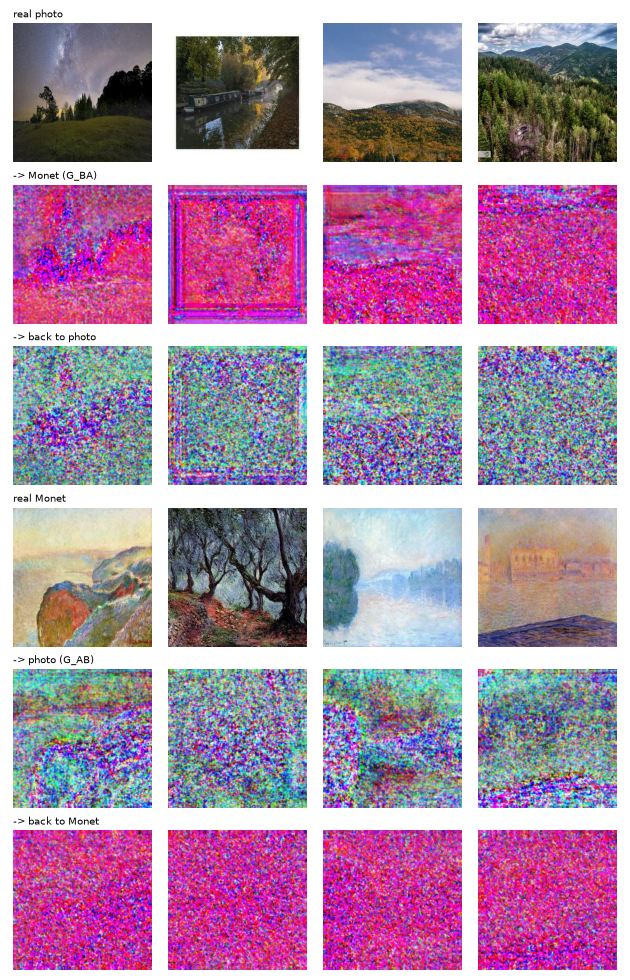

In [9]:
from IPython.display import Image as IPImage, display

REPO_ROOT = TASK_DIR.parent
LOG_DIR = REPO_ROOT / "reproducibility" / "raw_logs"; LOG_DIR.mkdir(parents=True, exist_ok=True)
CKPT_DIR = MEMBER_DIR / "checkpoints"; CKPT_DIR.mkdir(exist_ok=True)
SAMPLE_DIR = OUT_DIR / "training_samples"; SAMPLE_DIR.mkdir(exist_ok=True)
RUN_ID = time.strftime("%Y%m%d_%H%M%S") + ("_smoke" if SMOKE else "")
LOG_PATH = LOG_DIR / f"manjot_task3_{RUN_ID}.csv"
CKPT_EVERY = 1 if SMOKE else 5        # save generator weights every N epochs (each save ~91 MB)

# ---- fresh start: undo the 3 test updates from the previous cell ----
torch.manual_seed(SEED)
for m in (G_AB, G_BA, D_A, D_B):
    m.apply(init_weights)
opt_G = torch.optim.Adam(itertools.chain(G_AB.parameters(), G_BA.parameters()), lr=TRAIN["lr"], betas=TRAIN["betas"])
opt_D = torch.optim.Adam(itertools.chain(D_A.parameters(), D_B.parameters()), lr=TRAIN["lr"], betas=TRAIN["betas"])
sched_G = torch.optim.lr_scheduler.LambdaLR(opt_G, lr_factor)
sched_D = torch.optim.lr_scheduler.LambdaLR(opt_D, lr_factor)
pool_A, pool_B = ImagePool(TRAIN["pool_size"]), ImagePool(TRAIN["pool_size"])

# ---- the same 4 Monets + 4 photos are translated during training, so progress is easy to compare ----
eval_tf = T.Compose([T.ToTensor(), T.Normalize([0.5] * 3, [0.5] * 3)])   # no augmentation
fixed_A = torch.stack([eval_tf(Image.open(f).convert("RGB")) for f in monet_files[:4]]).to(device)
fixed_B = torch.stack([eval_tf(Image.open(f).convert("RGB"))
                       for f in random.Random(SEED).sample(photo_files, 4)]).to(device)

@torch.no_grad()
def save_samples(tag):
    G_AB.eval(); G_BA.eval()
    with autocast_ctx():
        fA = G_BA(fixed_B); rB = G_AB(fA)      # photo -> Monet -> photo
        fB = G_AB(fixed_A); rA = G_BA(fB)      # Monet -> photo -> Monet
    G_AB.train(); G_BA.train()
    rows = [fixed_B, fA, rB, fixed_A, fB, rA]
    titles = ["real photo", "-> Monet (G_BA)", "-> back to photo",
              "real Monet", "-> photo (G_AB)", "-> back to Monet"]
    fig, ax = plt.subplots(6, 4, figsize=(9, 14))
    for r, (imgs, t) in enumerate(zip(rows, titles)):
        for c in range(4):
            ax[r, c].imshow(to_img(imgs[c:c + 1].float().cpu())); ax[r, c].axis("off")
        ax[r, 0].set_title(t, loc="left", fontsize=10)
    plt.tight_layout()
    path = SAMPLE_DIR / f"{RUN_ID}_{tag}.png"
    plt.savefig(path, dpi=70); plt.close(fig)
    return path

def save_checkpoint(epoch, step, final=False):
    # 1) full state, overwritten each epoch -> lets us resume if the GPU session dies
    torch.save({"G_AB": G_AB.state_dict(), "G_BA": G_BA.state_dict(),
                "D_A": D_A.state_dict(), "D_B": D_B.state_dict(),
                "opt_G": opt_G.state_dict(), "opt_D": opt_D.state_dict(),
                "sched_G": sched_G.state_dict(), "sched_D": sched_D.state_dict(),
                "epoch": epoch, "step": step, "G_CFG": G_CFG, "D_CFG": D_CFG, "TRAIN": TRAIN,
                "run_id": RUN_ID}, CKPT_DIR / f"{RUN_ID}_last_full.pt")
    # 2) generators only, kept every CKPT_EVERY epochs -> used for inference / evaluation
    if final or (epoch + 1) % CKPT_EVERY == 0:
        torch.save({"G_AB": G_AB.state_dict(), "G_BA": G_BA.state_dict(), "G_CFG": G_CFG,
                    "epoch": epoch, "step": step, "run_id": RUN_ID},
                   CKPT_DIR / f"{RUN_ID}_generators_epoch{epoch + 1}.pt")

print("run id:", RUN_ID)
print("log file:", LOG_PATH.name)
p = save_samples("step0_untrained")
display(IPImage(filename=str(p)))

steps per epoch: 30   total steps: 60
DiffAugment on D_A / D_B: True True


real features for quick FID: (20, 2048) Monet, (20, 2048) photo (0s)


ep 1 step      0 | lr 2.0e-04 | G 18.259 (cyc 0.653/0.586) | D 4.023 | gn 145.1/75.2 | nan 0 | 2.6 img/s


ep 1 step      5 | lr 2.0e-04 | G 19.367 (cyc 0.591/0.769) | D 3.455 | gn 152.3/78.5 | nan 0 | 13.8 img/s


ep 1 step     10 | lr 2.0e-04 | G 12.262 (cyc 0.567/0.356) | D 1.852 | gn 107.6/43.1 | nan 0 | 13.9 img/s


...

ep 2 step     45 | lr 2.0e-04 | G 7.352 (cyc 0.246/0.333) | D 1.393 | gn 110.1/46.3 | nan 0 | 14.2 img/s


ep 2 step     50 | lr 2.0e-04 | G 5.971 (cyc 0.191/0.259) | D 0.857 | gn 55.2/20.9 | nan 0 | 13.9 img/s


ep 2 step     55 | lr 2.0e-04 | G 5.755 (cyc 0.200/0.235) | D 0.818 | gn 57.9/34.7 | nan 0 | 13.9 img/s


ep 2 step     59 | lr 2.0e-04 | G 9.962 (cyc 0.408/0.423) | D 0.744 | gn 56.4/10.0 | nan 0 | 14.0 img/s


=== epoch 2/2 | quick FID B2A 316.89  A2B 321.65  avg 319.27 | best 319.27 (epoch 2) | 150s ===
{'run_id': '20261004_053047_smoke', 'steps': 60, 'epochs': 2, 'steps_per_epoch': 30, 'total_time': 149.9, 'total_time_s': 149.9, 'quick_fid_time_s': 144.0, 'nan_count': 0, 'peak_mem_gb': 2.218912768, 'params_total': 28285832, 'diffaug': True, 'best_epoch': 2, 'best_quick_fid_avg': 319.26646684601263}
epoch,fid_b2a,fid_a2b,fid_avg,best_so_far
1,325.109,337.127,331.118,331.118
2,316.886,321.647,319.266,319.266

loaded best generators: epoch 2, quick FID avg 319.27


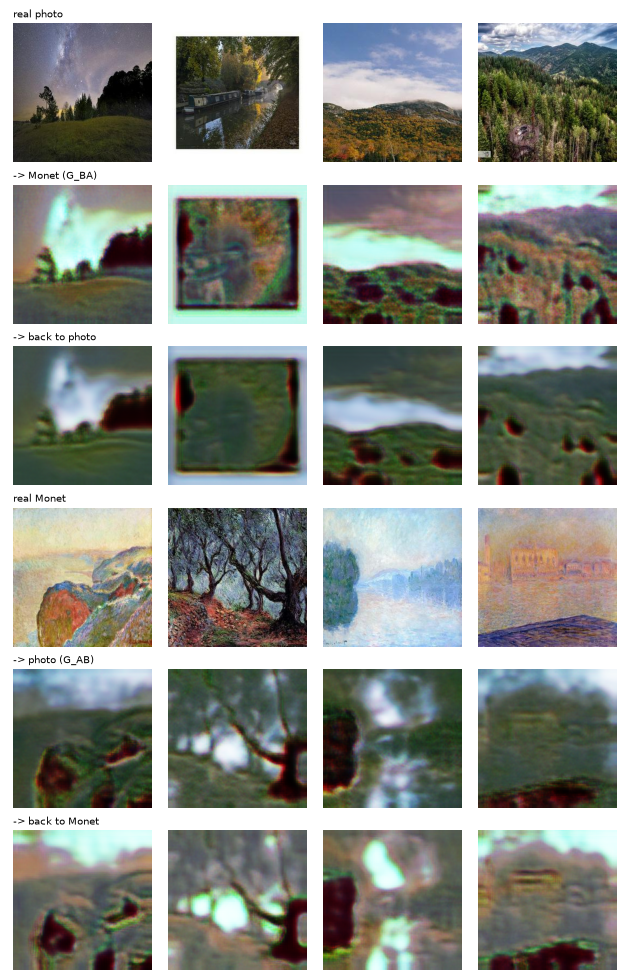

In [10]:
from torch.utils.data import DataLoader
import scipy.linalg
import torchvision.models as tvm

train_dl = DataLoader(ds, batch_size=TRAIN["batch_size"], shuffle=True, drop_last=True,
                      num_workers=4 if device == "cuda" else 0,
                      pin_memory=(device == "cuda"), persistent_workers=(device == "cuda"))
steps_per_epoch = TRAIN["steps_per_epoch"] or len(train_dl)
total_steps = steps_per_epoch * TRAIN["epochs"]
print(f"steps per epoch: {steps_per_epoch}   total steps: {total_steps}")

# ---- DiffAugment: wrap the discriminators AFTER the fresh re-init above (same parameters -> optimisers still valid) ----
if TRAIN["diffaug"] and not isinstance(D_A, AugD):
    D_A = AugD(D_A)
if TRAIN["diffaug"] and not isinstance(D_B, AugD):
    D_B = AugD(D_B)
print("DiffAugment on D_A / D_B:", isinstance(D_A, AugD), isinstance(D_B, AugD))

CKPT_EVERY = 1 if SMOKE else 50       # epochs between checkpoints (generators file ~91 MB each)
FID_HIST_PATH = LOG_PATH.parent / f"manjot_task3_{RUN_ID}_fid_history.csv"
BEST_PATH = CKPT_DIR / f"{RUN_ID}_generators_best.pt"

# save the exact settings of this run next to its log
(LOG_DIR / f"manjot_task3_{RUN_ID}_config.json").write_text(json.dumps(
    {"G": G_CFG, "D": D_CFG, "train": TRAIN, "seed": SEED, "device": device,
     "gpu": torch.cuda.get_device_name(0) if device == "cuda" else device,
     "torch": torch.__version__, "params_G_each": n_g, "params_D_each": n_d}, indent=1))

# ---- quick FID during training (same Inception-v3 setup as the evaluation cell further down) ----
fid_net = tvm.inception_v3(weights=tvm.Inception_V3_Weights.IMAGENET1K_V1, transform_input=False)
fid_net.fc = nn.Identity()
fid_net = fid_net.to(device).eval()
QFID_TF = T.Compose([T.Resize(299, antialias=True), T.CenterCrop(299),
                     T.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225))])   # input: tensors in [0, 1]
QF_MONETS, QF_PHOTOS = monet_files[:TRAIN["n_fid"]], photo_files[:TRAIN["n_fid"]]   # first n_fid sorted files

def qfid_feats(batches):
    return np.concatenate([fid_net(QFID_TF(x)).float().cpu().numpy() for x in batches]).astype(np.float64)

def real_batches(files, bs=32):
    for i in range(0, len(files), bs):
        yield torch.stack([T.functional.to_tensor(Image.open(f).convert("RGB")) for f in files[i:i + bs]]).to(device)

def fake_batches(G, files, bs=16):
    for i in range(0, len(files), bs):
        x = torch.stack([eval_tf(Image.open(f).convert("RGB")) for f in files[i:i + bs]]).to(device)
        with autocast_ctx():
            y = G(x)
        yield ((y.float().clamp(-1, 1) + 1) * 127.5).round() / 255   # [-1,1] -> 8-bit levels in [0,1], like saved JPGs

def frechet(f1, f2, eps=1e-6):
    mu1, mu2 = f1.mean(0), f2.mean(0)
    s1, s2 = np.cov(f1, rowvar=False), np.cov(f2, rowvar=False)
    covmean = scipy.linalg.sqrtm(s1 @ s2)
    covmean = covmean[0] if isinstance(covmean, tuple) else covmean
    if not np.isfinite(covmean).all():
        off = np.eye(len(s1)) * eps
        covmean = scipy.linalg.sqrtm((s1 + off) @ (s2 + off))
        covmean = covmean[0] if isinstance(covmean, tuple) else covmean
    d = mu1 - mu2
    return float(d @ d + np.trace(s1 + s2 - 2 * covmean.real))

def quick_fid():
    """FID(G_BA(photos) vs real Monets), FID(G_AB(Monets) vs real photos) and their average."""
    G_AB.eval(); G_BA.eval()
    try:
        with torch.no_grad():
            f_b2a = qfid_feats(fake_batches(G_BA, QF_PHOTOS))
            f_a2b = qfid_feats(fake_batches(G_AB, QF_MONETS))
    finally:
        G_AB.train(); G_BA.train()
    fid_b2a, fid_a2b = frechet(QF_REAL_MONET, f_b2a), frechet(QF_REAL_PHOTO, f_a2b)
    return fid_b2a, fid_a2b, (fid_b2a + fid_a2b) / 2

t0 = time.time()
with torch.no_grad():
    QF_REAL_MONET, QF_REAL_PHOTO = qfid_feats(real_batches(QF_MONETS)), qfid_feats(real_batches(QF_PHOTOS))
print(f"real features for quick FID: {QF_REAL_MONET.shape} Monet, {QF_REAL_PHOTO.shape} photo ({time.time() - t0:.0f}s)")

# ---- main loop ----
def endless(loader):
    while True:              # restart the DataLoader whenever it is exhausted
        yield from loader

if device == "cuda":
    torch.cuda.reset_peak_memory_stats()

batches = endless(train_dl)
step, nan_total, t_start = 0, 0, time.time()
t_log, n_since_log, fid_time = time.time(), 0, 0.0
best_fid, best_epoch = float("inf"), None
header_done = False

with open(LOG_PATH, "w", newline="") as f, open(FID_HIST_PATH, "w", newline="") as fh:
    log, fid_log = csv.writer(f), csv.writer(fh)
    fid_log.writerow(["epoch", "fid_b2a", "fid_a2b", "fid_avg", "best_so_far"])
    for epoch in range(TRAIN["epochs"]):
        for _ in range(steps_per_epoch):
            ra, rb = next(batches)
            s = train_step(ra.to(device, non_blocking=True), rb.to(device, non_blocking=True))
            nan_total += s["nan"]; n_since_log += ra.size(0)
            if step % TRAIN["log_every"] == 0 or step == total_steps - 1:
                now = time.time()
                ips = n_since_log / max(now - t_log, 1e-9)    # average throughput since the last log row
                t_log, n_since_log = now, 0
                lr = opt_G.param_groups[0]["lr"]
                if not header_done:
                    log.writerow(["step", "epoch", "lr"] + list(s) + ["imgs_per_sec", "elapsed_s"])
                    header_done = True
                log.writerow([step, epoch, f"{lr:.3e}"] + [f"{v:.5f}" if isinstance(v, float) else v for v in s.values()]
                             + [f"{ips:.2f}", f"{now - t_start:.1f}"])
                f.flush()                                   # write the log to disk regularly
                print(f"ep {epoch + 1} step {step:6d} | lr {lr:.1e} | G {s['loss_G']:.3f} "
                      f"(cyc {s['cyc_A']:.3f}/{s['cyc_B']:.3f}) | D {s['loss_D']:.3f} | "
                      f"gn {s['gn_G']:.1f}/{s['gn_D']:.1f} | nan {s['nan']} | {ips:.1f} img/s")
            if step > 0 and step % TRAIN["sample_every"] == 0:
                save_samples(f"ep{epoch + 1:03d}_step{step:06d}")
            step += 1

        sched_G.step(); sched_D.step()                      # learning-rate schedule moves once per epoch
        final = epoch == TRAIN["epochs"] - 1
        if (epoch + 1) % CKPT_EVERY == 0 or final:
            save_checkpoint(epoch, step, final=final)

        if (epoch + 1) % TRAIN["eval_every"] == 0 or final:
            t0 = time.time()
            fid_b2a_q, fid_a2b_q, fid_avg_q = quick_fid()
            fid_time += time.time() - t0
            if fid_avg_q < best_fid:                        # keep the generators with the best quick FID
                best_fid, best_epoch = fid_avg_q, epoch + 1
                torch.save({"G_AB": G_AB.state_dict(), "G_BA": G_BA.state_dict(),
                            "epoch": best_epoch, "fid": best_fid}, BEST_PATH)
            fid_log.writerow([epoch + 1, f"{fid_b2a_q:.3f}", f"{fid_a2b_q:.3f}", f"{fid_avg_q:.3f}", f"{best_fid:.3f}"])
            fh.flush()
            print(f"=== epoch {epoch + 1}/{TRAIN['epochs']} | quick FID B2A {fid_b2a_q:.2f}  A2B {fid_a2b_q:.2f}  "
                  f"avg {fid_avg_q:.2f} | best {best_fid:.2f} (epoch {best_epoch}) | {time.time() - t_start:.0f}s ===")

total_time = time.time() - t_start
peak_mem_gb = torch.cuda.max_memory_allocated() / 1e9 if device == "cuda" else None
summary = {"run_id": RUN_ID, "steps": step, "epochs": TRAIN["epochs"], "steps_per_epoch": steps_per_epoch,
           "total_time": round(total_time, 1), "total_time_s": round(total_time, 1),
           "quick_fid_time_s": round(fid_time, 1), "nan_count": nan_total, "peak_mem_gb": peak_mem_gb,
           "params_total": 2 * n_g + 2 * n_d, "diffaug": TRAIN["diffaug"],
           "best_epoch": best_epoch, "best_quick_fid_avg": best_fid if best_epoch is not None else None}
(LOG_PATH.parent / f"manjot_task3_{RUN_ID}_summary.json").write_text(json.dumps(summary, indent=1))
print(summary)
print(FID_HIST_PATH.read_text())

# ---- use the BEST epoch from here on (translate_folder, metrics, ...) ----
if BEST_PATH.exists():
    best = torch.load(BEST_PATH, map_location=device)
    G_AB.load_state_dict(best["G_AB"]); G_BA.load_state_dict(best["G_BA"])
    print(f"loaded best generators: epoch {best['epoch']}, quick FID avg {best['fid']:.2f}")
p = save_samples(f"best_ep{best_epoch}")
display(IPImage(filename=str(p)))

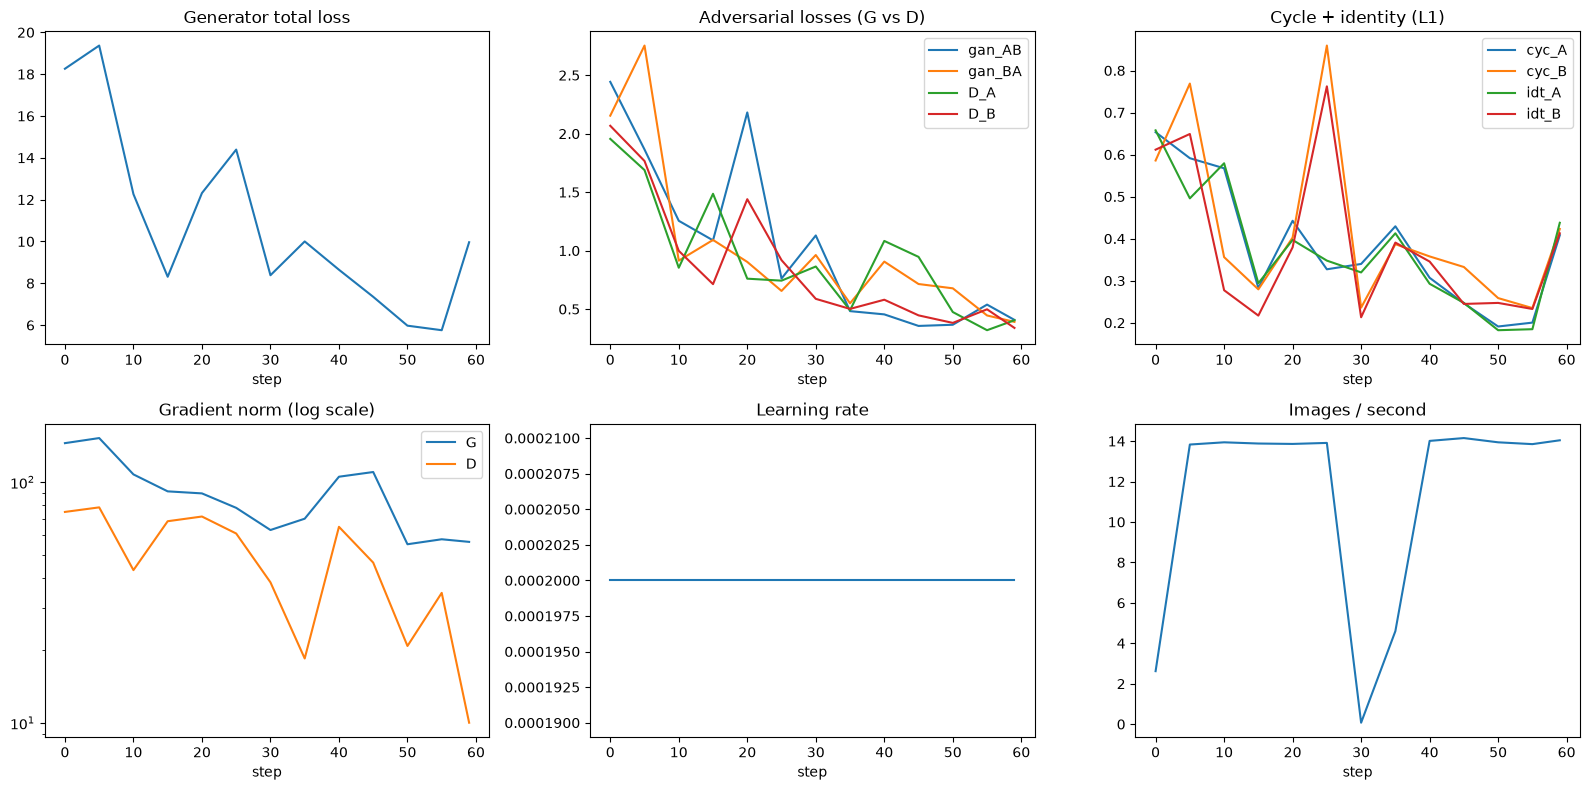

NaN steps: 0 | steps logged: 13


In [11]:
import pandas as pd

logdf = pd.read_csv(LOG_PATH)
w = max(1, min(200, len(logdf) // 10))                   # smoothing window (small for the smoke run)
sm = lambda c: logdf[c].rolling(w, min_periods=1).mean()

fig, ax = plt.subplots(2, 3, figsize=(16, 8))
ax[0, 0].plot(logdf.step, sm("loss_G")); ax[0, 0].set_title("Generator total loss")
for c in ["gan_AB", "gan_BA", "D_A", "D_B"]:
    ax[0, 1].plot(logdf.step, sm(c), label=c)
ax[0, 1].set_title("Adversarial losses (G vs D)"); ax[0, 1].legend()
for c in ["cyc_A", "cyc_B", "idt_A", "idt_B"]:
    ax[0, 2].plot(logdf.step, sm(c), label=c)
ax[0, 2].set_title("Cycle + identity (L1)"); ax[0, 2].legend()
ax[1, 0].plot(logdf.step, sm("gn_G"), label="G"); ax[1, 0].plot(logdf.step, sm("gn_D"), label="D")
ax[1, 0].set_yscale("log"); ax[1, 0].set_title("Gradient norm (log scale)"); ax[1, 0].legend()
ax[1, 1].plot(logdf.step, logdf.lr); ax[1, 1].set_title("Learning rate")
ax[1, 2].plot(logdf.step, sm("imgs_per_sec")); ax[1, 2].set_title("Images / second")
for a in ax.flat:
    a.set_xlabel("step")
plt.tight_layout()
plt.savefig(OUT_DIR / f"training_curves_{RUN_ID}.png", dpi=120)
plt.show()
print("NaN steps:", int(logdf["nan"].sum()), "| steps logged:", len(logdf))

pred_B2A (photo->Monet): 20 images | 61.2 img/s
pred_A2B (Monet->photo): 20 images | 103.4 img/s


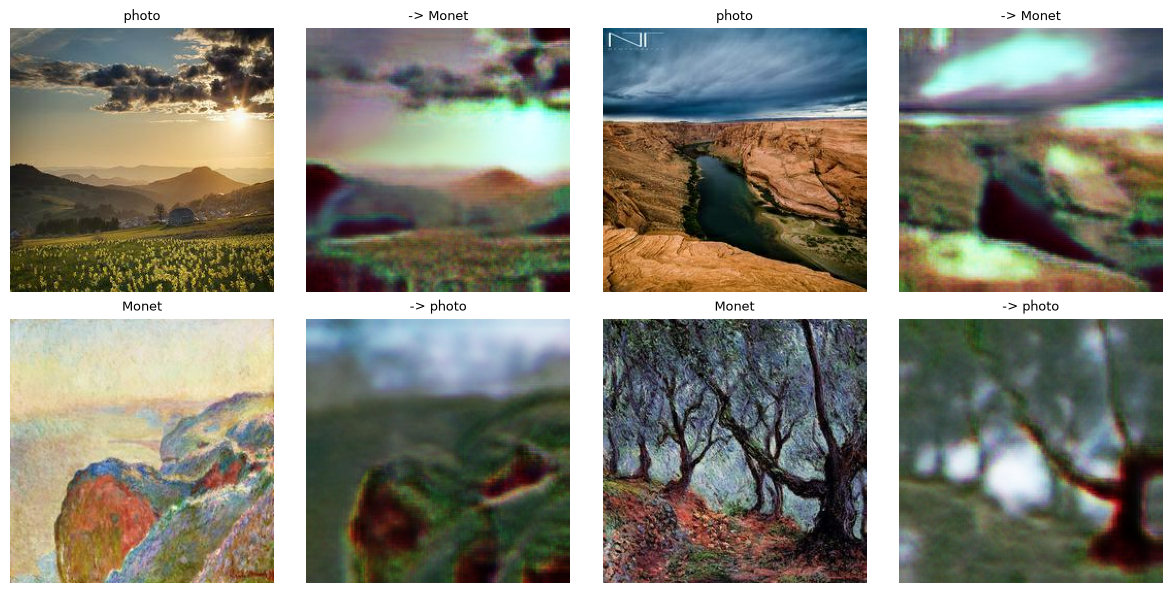

In [12]:
import shutil

PRED_A2B, PRED_B2A = OUT_DIR / "pred_A2B", OUT_DIR / "pred_B2A"
N_PHOTO = 20 if SMOKE else len(photo_files)     # photos to turn into Monet paintings
N_MONET = 20 if SMOKE else len(monet_files)     # Monets to turn into photos

@torch.no_grad()
def translate_folder(G, files, out_dir, bs=16):
    """Run generator G over `files` and save each result as a 256x256 JPG with the SAME filename."""
    if out_dir.exists():
        shutil.rmtree(out_dir)                  # start clean so no old images get scored
    out_dir.mkdir(parents=True)
    G.eval(); t0 = time.time()
    for i in range(0, len(files), bs):
        chunk = files[i:i + bs]
        x = torch.stack([eval_tf(Image.open(f).convert("RGB")) for f in chunk]).to(device)
        with autocast_ctx():
            y = G(x)
        y = ((y.float().clamp(-1, 1) + 1) * 127.5).round().to(torch.uint8)   # [-1,1] -> 0..255
        for f, arr in zip(chunk, y.permute(0, 2, 3, 1).cpu().numpy()):
            Image.fromarray(arr).save(out_dir / Path(f).name, quality=95)
    G.train()
    return len(files) / (time.time() - t0)      # images per second

gen_ips_B2A = translate_folder(G_BA, photo_files[:N_PHOTO], PRED_B2A)   # photo -> Monet
gen_ips_A2B = translate_folder(G_AB, monet_files[:N_MONET], PRED_A2B)   # Monet -> photo
print(f"pred_B2A (photo->Monet): {len(os.listdir(PRED_B2A))} images | {gen_ips_B2A:.1f} img/s")
print(f"pred_A2B (Monet->photo): {len(os.listdir(PRED_A2B))} images | {gen_ips_A2B:.1f} img/s")

# side-by-side check: input vs output, read back from disk
fig, ax = plt.subplots(2, 4, figsize=(12, 6))
for c in range(2):
    name = Path(photo_files[c]).name
    ax[0, 2*c].imshow(Image.open(photo_files[c])); ax[0, 2*c].set_title("photo", fontsize=9)
    ax[0, 2*c+1].imshow(Image.open(PRED_B2A / name)); ax[0, 2*c+1].set_title("-> Monet", fontsize=9)
    name = Path(monet_files[c]).name
    ax[1, 2*c].imshow(Image.open(monet_files[c])); ax[1, 2*c].set_title("Monet", fontsize=9)
    ax[1, 2*c+1].imshow(Image.open(PRED_A2B / name)); ax[1, 2*c+1].set_title("-> photo", fontsize=9)
for a in ax.flat:
    a.axis("off")
plt.tight_layout(); plt.show()

In [13]:
import scipy.linalg
from scipy.spatial.distance import cdist
import torchvision.models as tvm

# Inception-v3 exactly as in the class evaluation script (pretrained ONLY for scoring, never for generation)
inception = tvm.inception_v3(weights=tvm.Inception_V3_Weights.IMAGENET1K_V1, transform_input=False)
inception.fc = nn.Identity()
inception = inception.to(device).eval()
INC_TF = T.Compose([T.Resize(299), T.CenterCrop(299), T.ToTensor(),
                    T.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225))])

@torch.no_grad()
def inception_feats(paths, bs=32):
    out = []
    for i in range(0, len(paths), bs):
        x = torch.stack([INC_TF(Image.open(p).convert("RGB")) for p in paths[i:i + bs]]).to(device)
        out.append(inception(x).float().cpu().numpy())
    return np.concatenate(out).astype(np.float64)          # (N, 2048)

def fid_from_stats(mu1, s1, mu2, s2, eps=1e-6):
    covmean = scipy.linalg.sqrtm(s1 @ s2)
    covmean = covmean[0] if isinstance(covmean, tuple) else covmean
    if not np.isfinite(covmean).all():
        off = np.eye(len(s1)) * eps
        covmean = scipy.linalg.sqrtm((s1 + off) @ (s2 + off))
        covmean = covmean[0] if isinstance(covmean, tuple) else covmean
    d = mu1 - mu2
    return float(d @ d + np.trace(s1 + s2 - 2 * covmean.real))

def fid(f_real, f_gen):
    return fid_from_stats(f_real.mean(0), np.cov(f_real, rowvar=False),
                          f_gen.mean(0), np.cov(f_gen, rowvar=False))

def kid(f_real, f_gen, n_sub=50, sub=100, seed=0):
    """Kernel Inception Distance (unbiased MMD, cubic polynomial kernel). Returns mean, std over subsets."""
    rng, d = np.random.default_rng(seed), f_real.shape[1]
    m = min(sub, len(f_real), len(f_gen)); vals = []
    for _ in range(n_sub):
        x = f_real[rng.choice(len(f_real), m, replace=False)]
        y = f_gen[rng.choice(len(f_gen), m, replace=False)]
        kxx, kyy, kxy = (x @ x.T / d + 1) ** 3, (y @ y.T / d + 1) ** 3, (x @ y.T / d + 1) ** 3
        vals.append((kxx.sum() - np.trace(kxx)) / (m * (m - 1))
                    + (kyy.sum() - np.trace(kyy)) / (m * (m - 1)) - 2 * kxy.mean())
    return float(np.mean(vals)), float(np.std(vals))

def precision_recall(f_real, f_gen, k=3):
    """k-NN precision (are fakes realistic?) and recall (do fakes cover the variety of real images?)."""
    r_rad = np.sort(cdist(f_real, f_real), 1)[:, k]        # column 0 is the point itself
    g_rad = np.sort(cdist(f_gen, f_gen), 1)[:, k]
    d_rg = cdist(f_real, f_gen)
    precision = float((d_rg <= r_rad[:, None]).any(0).mean())
    recall = float((d_rg <= g_rad[None, :]).any(1).mean())
    return precision, recall

def mifid_cos(f_real, f_gen):
    """'MiFID' as defined in the class script: mean cosine distance between index-paired features."""
    m = min(len(f_real), len(f_gen))
    a, b = f_real[:m], f_gen[:m]
    cos = (a * b).sum(1) / (np.linalg.norm(a, axis=1) * np.linalg.norm(b, axis=1))
    return float(np.mean(1 - cos))

# ---- sanity check: does real_stats.npz match OUR feature extractor? ----
t0 = time.time()
f_real_monet = inception_feats(monet_files)                # all 300 real Monets
print(f"Inception features for 300 Monets: {f_real_monet.shape} in {time.time() - t0:.0f}s")
fid_vs_npz = fid_from_stats(f_real_monet.mean(0), np.cov(f_real_monet, rowvar=False),
                            stats["mu_real"].astype(np.float64), stats["sigma_real"])
print(f"FID(our real-Monet features vs real_stats.npz) = {fid_vs_npz:.3f}   (≈0 means same extractor)")
print("max |mu difference|:", float(np.abs(f_real_monet.mean(0) - stats["mu_real"]).max()))


Inception features for 300 Monets: (300, 2048) in 4s


FID(our real-Monet features vs real_stats.npz) = 20.595   (≈0 means same extractor)
max |mu difference|: 0.2791360776793833


In [14]:
cos_rows = lambda a, b: (a * b).sum(1) / (np.linalg.norm(a, axis=1) * np.linalg.norm(b, axis=1))
npz32 = stats["feats_real"][:32].astype(np.float64)

# same 32 Monets, computed on CPU instead of the Mac GPU
inception.to("cpu")
with torch.no_grad():
    x = torch.stack([INC_TF(Image.open(p).convert("RGB")) for p in monet_files[:32]])
    f_cpu = inception(x).numpy().astype(np.float64)
inception.to(device)

print(f"cosine  ours(MPS) vs npz : {cos_rows(f_real_monet[:32], npz32).mean():.4f}")
print(f"cosine  ours(CPU) vs npz : {cos_rows(f_cpu, npz32).mean():.4f}")
print(f"cosine  ours(CPU) vs MPS : {cos_rows(f_cpu, f_real_monet[:32]).mean():.4f}")

cosine  ours(MPS) vs npz : 0.9630
cosine  ours(CPU) vs npz : 0.9630
cosine  ours(CPU) vs MPS : 1.0000


In [15]:
import lpips, torch.nn.functional as F

lpips_fn = lpips.LPIPS(net="alex", verbose=False).to(device).eval()   # pretrained ONLY for scoring

def ssim_gray(x, y):
    """SSIM on luminance (structure kept?) for images in [-1, 1], shape (B, 3, H, W)."""
    w = torch.tensor([0.299, 0.587, 0.114], device=x.device).view(1, 3, 1, 1)
    x = ((x + 1) / 2 * w).sum(1, keepdim=True); y = ((y + 1) / 2 * w).sum(1, keepdim=True)
    g = torch.exp(-((torch.arange(11, device=x.device) - 5.0) ** 2) / (2 * 1.5 ** 2)); g = g / g.sum()
    k = (g[:, None] * g[None, :]).view(1, 1, 11, 11)
    f = lambda t: F.conv2d(t, k)
    mx, my = f(x), f(y)
    sxx, syy, sxy = f(x * x) - mx ** 2, f(y * y) - my ** 2, f(x * y) - mx * my
    C1, C2 = 0.01 ** 2, 0.03 ** 2
    return (((2 * mx * my + C1) * (2 * sxy + C2)) / ((mx ** 2 + my ** 2 + C1) * (sxx + syy + C2))).mean((1, 2, 3))

@torch.no_grad()
def paired_metrics(G_fwd, G_back, files, bs=16):
    """cycle L1 (x -> y -> x), LPIPS(x, y) and SSIM(x, y) averaged over `files`."""
    cyc, lp, ss = [], [], []
    G_fwd.eval(); G_back.eval()
    for i in range(0, len(files), bs):
        x = torch.stack([eval_tf(Image.open(f).convert("RGB")) for f in files[i:i + bs]]).to(device)
        with autocast_ctx():
            y = G_fwd(x); r = G_back(y)
        y, r = y.float().clamp(-1, 1), r.float().clamp(-1, 1)
        cyc.append((r - x).abs().mean((1, 2, 3)).cpu())
        lp.append(lpips_fn(x, y).flatten().cpu())
        ss.append(ssim_gray(x, y).cpu())
    G_fwd.train(); G_back.train()
    return [float(torch.cat(v).mean()) for v in (cyc, lp, ss)]

# ---------- distribution metrics (same pairing rule as the class script: first n of each, sorted) ----------
gen_b2a = sorted(glob.glob(str(PRED_B2A / "*.jpg")))
gen_a2b = sorted(glob.glob(str(PRED_A2B / "*.jpg")))
n_eval = min(300, len(gen_b2a), len(gen_a2b))
t0 = time.time()
f_gen_b2a = inception_feats(gen_b2a[:n_eval])
f_gen_a2b = inception_feats(gen_a2b[:n_eval])
f_real_photo = inception_feats(photo_files[:n_eval])
fr_monet = f_real_monet[:n_eval]

fid_b2a, fid_a2b = fid(fr_monet, f_gen_b2a), fid(f_real_photo, f_gen_a2b)
fid_b2a_npz = fid_from_stats(stats["mu_real"].astype(np.float64), stats["sigma_real"],
                             f_gen_b2a.mean(0), np.cov(f_gen_b2a, rowvar=False))
kid_b2a, kid_b2a_sd = kid(fr_monet, f_gen_b2a)
kid_a2b, kid_a2b_sd = kid(f_real_photo, f_gen_a2b)
prec_b2a, rec_b2a = precision_recall(fr_monet, f_gen_b2a)
prec_a2b, rec_a2b = precision_recall(f_real_photo, f_gen_a2b)
mifid_b2a, mifid_a2b = mifid_cos(fr_monet, f_gen_b2a), mifid_cos(f_real_photo, f_gen_a2b)

# ---------- content preservation: does the output keep the input's structure? ----------
cyc_B, lpips_b2a, ssim_b2a = paired_metrics(G_BA, G_AB, photo_files[:n_eval])   # photo -> Monet -> photo
cyc_A, lpips_a2b, ssim_a2b = paired_metrics(G_AB, G_BA, monet_files[:n_eval])   # Monet -> photo -> Monet
print(f"evaluation on n={n_eval} images per set took {time.time() - t0:.0f}s")

# ---------- training stability + efficiency (from the raw log) ----------
logdf = pd.read_csv(LOG_PATH)
tail = logdf.tail(max(1, len(logdf) // 20))            # last 5% of steps
metrics = {
    "run_id": RUN_ID, "n_eval_images": n_eval,
    "hardware": torch.cuda.get_device_name(0) if device == "cuda" else f"Apple Silicon ({device})",
    "FID_B2A_photo_to_monet": fid_b2a, "FID_B2A_vs_real_stats_npz": fid_b2a_npz,
    "FID_A2B_monet_to_photo": fid_a2b, "FID_kaggle_style_avg": (fid_a2b + fid_b2a) / 2,
    "MiFID_B2A": mifid_b2a, "MiFID_A2B": mifid_a2b, "MiFID_kaggle_style_avg": (mifid_a2b + mifid_b2a) / 2,
    "KID_B2A": kid_b2a, "KID_B2A_std": kid_b2a_sd, "KID_A2B": kid_a2b, "KID_A2B_std": kid_a2b_sd,
    "precision_B2A": prec_b2a, "recall_B2A": rec_b2a, "precision_A2B": prec_a2b, "recall_A2B": rec_a2b,
    "cycle_L1_A_monet": cyc_A, "cycle_L1_B_photo": cyc_B,
    "LPIPS_input_vs_output_B2A": lpips_b2a, "LPIPS_input_vs_output_A2B": lpips_a2b,
    "SSIM_content_B2A": ssim_b2a, "SSIM_content_A2B": ssim_a2b,
    "final_loss_G": tail.loss_G.mean(), "final_loss_D": tail.loss_D.mean(),
    "final_cyc_A": tail.cyc_A.mean(), "final_cyc_B": tail.cyc_B.mean(),
    "grad_norm_G_mean": logdf.gn_G.mean(), "grad_norm_G_max": logdf.gn_G.max(),
    "grad_norm_D_mean": logdf.gn_D.mean(), "grad_norm_D_max": logdf.gn_D.max(),
    "nan_count": int(logdf["nan"].sum()),
    "params_generator_each": n_g, "params_discriminator_each": n_d, "params_total": 2 * n_g + 2 * n_d,
    "train_imgs_per_sec_median": logdf.imgs_per_sec.iloc[min(10, len(logdf) - 1):].median(),
    "generation_imgs_per_sec_B2A": gen_ips_B2A,
    "peak_memory_gb": peak_mem_gb if peak_mem_gb is not None else "n/a (Mac)",
    "total_training_time_s": round(total_time, 1), "train_steps": int(logdf.step.max() + 1),
}
sfx = "_smoke" if SMOKE else ""
report = pd.DataFrame(list(metrics.items()), columns=["metric", "value"])
report.to_csv(MEMBER_DIR / f"full_metrics_report{sfx}.csv", index=False)
pd.DataFrame([{"ID": 1, "FID": metrics["FID_kaggle_style_avg"],
               "MiFID": metrics["MiFID_kaggle_style_avg"]}]).to_csv(OUT_DIR / f"submission{sfx}.csv", index=False)
report

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


evaluation on n=20 images per set took 96s


,metric,value
0,run_id,20261004_053047_smoke
1,n_eval_images,20
2,hardware,NVIDIA GeForce RTX 4090
3,FID_B2A_photo_to_monet,314.736151
4,FID_B2A_vs_real_stats_npz,303.074996
5,FID_A2B_monet_to_photo,318.625994
6,FID_kaggle_style_avg,316.681072
7,MiFID_B2A,0.459279
8,MiFID_A2B,0.50764
9,MiFID_kaggle_style_avg,0.483459
